# Dataset Description

A store opens its doors every week, stocks its shelves, adjusts for the weather, and tracks every dollar — but what actually drives the numbers? This dataset collects 6,435 weekly sales records across multiple Walmart store locations and is focused on the question of whether external economic and environmental conditions influence retail sales performance. A number of characteristics about each store's surrounding environment are included in each row.

# Columns Description

1. `Store`        : Unique numeric identifier assigned to each Walmart store location.
2. `Date`         : The week during which sales were recorded (MM/DD/YYYY).
3. `Weekly_Sales` : Total revenue generated by the store for that given week, measured in US dollars.
4. `Holiday_Flag` : Binary indicator of whether the week coincided with a public holiday (1 = Holiday week, 0 = Regular week).
5. `Temperature`  : Average regional temperature (in Fahrenheit) recorded during that week.
6. `Fuel_Price`   : Average cost of fuel (in USD per gallon) in the store's surrounding region for that week.
7. `CPI`          : Consumer Price Index reflecting the local cost of living and inflation level at the time of recording.
8. `Unemployment` : Regional unemployment rate (%) representing the economic conditions around the store during that week.

# EDA Ques 

### 1. Which store generates the highest total weekly sales?
### 2. Do holiday weeks lead to higher sales than non-holiday weeks?
### 3. Does temperature correlate with weekly sales?
### 4. Which month consistently generates the most revenue?


# Environment set-up

In [1]:
# importing lib.
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling

in this section, we'd load our data from a CSV file to a pandas dataframe, and then take a quick dive into exploring our dataset in details.

In [2]:
# loading dataset from csv file and showing its first 5 rows
df = pd.read_csv(r"C:\(Project)\Python\Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


We'll move next into exploring our dataset by going through its data types, NaNs or duplicated rows, and any columns that may need to be dropped or parsed.

In [3]:
# viewing main info about df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


- we can notice there are no NaNs at all in our dat
- `Store` has 45 unique store IDs — it acts as a label, not a number, so it should be cast to a category type.
- `Date` is stored as a plain string — it needs to be parsed into datetime.
- `Holiday_Flag` contains only 0 and 1 — it should be cast to boolean.


In [4]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

- our dataset has no duplicated rows either

In [5]:
# exploring the unique values of each column
df.nunique()

Store             45
Date             143
Weekly_Sales    6435
Holiday_Flag       2
Temperature     3528
Fuel_Price       892
CPI             2145
Unemployment     349
dtype: int64

# Statistical Summary 

In [6]:
df.describe().round(2)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00
mean,23.00,1046964.88,0.07,60.66,3.36,171.58,8.00
std,12.99,564366.62,0.26,18.44,0.46,39.36,1.88
min,1.00,209986.25,0.00,-2.06,2.47,126.06,3.88
25%,12.00,553350.10,0.00,47.46,2.93,131.74,6.89
50%,23.00,960746.04,0.00,62.67,3.44,182.62,7.87
75%,34.00,1420158.66,0.00,74.94,3.74,212.74,8.62
max,45.00,3818686.45,1.00,100.14,4.47,227.23,14.31


# Exploration Summery

1. Our dataset consists of 6435 rows with 8 columns, and has no NaNs nor duplicated values.
2. `Store`        : Unique numeric identifier assigned to each Walmart store location — 45 stores in total. It should be cast to a **category** type since it acts as a label, not a quantity.
3. `Date`         : Date string of the recorded sales week — needs to be **parsed into datetime** type to enable time-based analysis.
4. We may **append new columns** derived from `Date` such as `Year`, `Month`, and `Week_Number` for richer temporal analysis.
5. `Weekly_Sales` : The target variable representing weekly revenue per store — values range from **~$209K to ~$3.8M**, all unique, correctly typed.
6. `Holiday_Flag` : Contains only `0` and `1` — marks whether the week includes a public holiday. Should be cast to **boolean** type.
7. `Temperature`  : Records the regional temperature for the week — contains a **negative minimum value (-2.06°F)** that may need to be investigated.
8. `Fuel_Price`   : Weekly regional fuel price — continuous numeric, no issues detected.
9. `CPI`          : Consumer Price Index per store region — wide range (**126 to 227**) reflecting different store locations and time periods, correctly typed.
10. `Unemployment` : Regional unemployment rate per store — values range from **3.87% to 14.31%**, correctly typed.

__________________________________________________________________________________________________________________________________________

# Data Cleaning


in this section, we'd perform some operations on our dataset based on the previous findings to make our analysis more accurate and clear

In [7]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

- There is no null value in the dataset

__________________________________________________________________________________________________________________________________________

**Fix `Date` column**

In [8]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract useful time features
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week']  = df['Date'].dt.isocalendar().week.astype(int)

df[['Date', 'Year', 'Month', 'Week']].head()

,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


Breaking the `date` into Year, Month, and Day columns allows to understand the time periods

__________________________________________________________________________________________________________________________________________

In [9]:
# viewing negative weekly_Sales values
neg_sales = df[df['Weekly_Sales'] < 0]
print(f'Negative Weekly_Sales records: {len(neg_sales)}')

Negative Weekly_Sales records: 0


There is no negative values in the `Weekly_Sales` column 

__________________________________________________________________________________________________________________________________________

**Rename `Holiday_Flag` for clarity**

In [10]:
df['Holiday_Flag'] = df['Holiday_Flag'].map({0: 'Non-Holiday', 1: 'Holiday'})

print(f'Cleaned Dataset Shape: {df.shape}')
df.head()

Cleaned Dataset Shape: (6435, 11)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,Non-Holiday,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,Holiday,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,Non-Holiday,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,Non-Holiday,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,Non-Holiday,46.50,2.625,211.350143,8.106,2010,3,9


In [11]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,Non-Holiday,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,Holiday,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,Non-Holiday,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,Non-Holiday,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,Non-Holiday,46.50,2.625,211.350143,8.106,2010,3,9


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   object        
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Week          6435 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int32(2), int64(2), object(1)
memory usage: 502.9+ KB


We endded up with a datafram of 6435 rows and 11 columns, and everything looks tidy and clean. We'd proceed in visualizing it to extract meaningful insights from it.

__________________________________________________________________________________________________________________________________________

# Data Visualization

Now that our data is clean, we'd perform some Data Visualization on it in order to extract useful insights from it.

#  Which store generates the highest total weekly sales?

In [13]:
c = df.groupby("Store").agg(Total_Sales=("Weekly_Sales", "sum")).round(2)\
     .sort_values("Total_Sales", ascending=False).reset_index().head(10)
c

,Store,Total_Sales
0,20,3.013978e+08
1,4,2.995440e+08
2,14,2.889999e+08
3,13,2.865177e+08
4,2,2.753824e+08
5,10,2.716177e+08
6,27,2.538559e+08
7,6,2.237561e+08
8,1,2.224028e+08
9,39,2.074455e+08


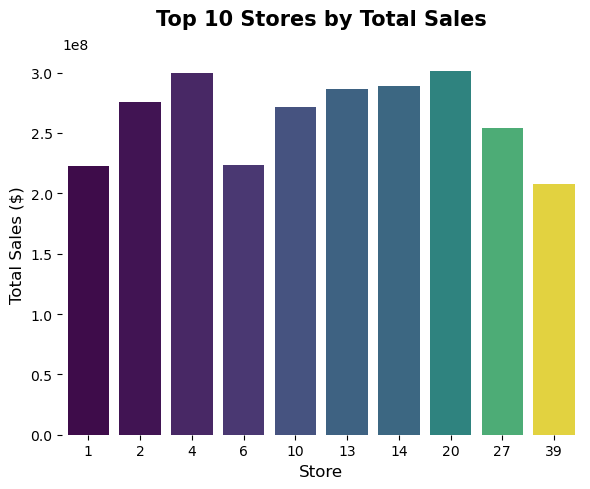

In [14]:
plt.figure(figsize=(6, 5))
ax = sns.barplot(
    data=c,
    x="Store",
    y="Total_Sales",
    palette="viridis",
    hue="Store",
    legend=False
)
plt.title("Top 10 Stores by Total Sales", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Store", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Do Holiday weeks have higher sales than Non-Holiday weeks?

In [15]:
c = df.groupby("Holiday_Flag").agg(Avg_Sales=("Weekly_Sales", "mean")).round(2).reset_index()
c

,Holiday_Flag,Avg_Sales
0,Holiday,1122887.89
1,Non-Holiday,1041256.38


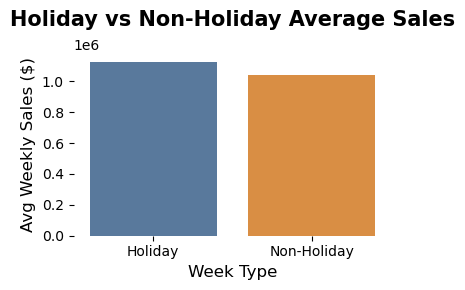

In [16]:
plt.figure(figsize=(4, 3))
ax = sns.barplot(
    data=c,
    x="Holiday_Flag",
    y="Avg_Sales",
    palette=["#4E79A7", "#F28E2B"],
    hue="Holiday_Flag",
    legend=False
)
plt.title("Holiday vs Non-Holiday Average Sales", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Week Type", fontsize=12)
plt.ylabel("Avg Weekly Sales ($)", fontsize=12)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# How does temperature affect sales?

In [17]:
bins   = [-10, 32, 60, 80, 110]
labels = ["Below 32°F", "32-60°F", "60-80°F", "Above 80°F"]

df["Temp_Group"] = pd.cut(df["Temperature"], bins=bins, labels=labels)

c = df.groupby("Temp_Group").agg(Avg_Sales=("Weekly_Sales", "mean")).round(2).reset_index()
c

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_19664\1234905133.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  c = df.groupby("Temp_Group").agg(Avg_Sales=("Weekly_Sales", "mean")).round(2).reset_index()


,Temp_Group,Avg_Sales
0,Below 32°F,1050917.57
1,32-60°F,1079583.86
2,60-80°F,1059193.19
3,Above 80°F,942056.53


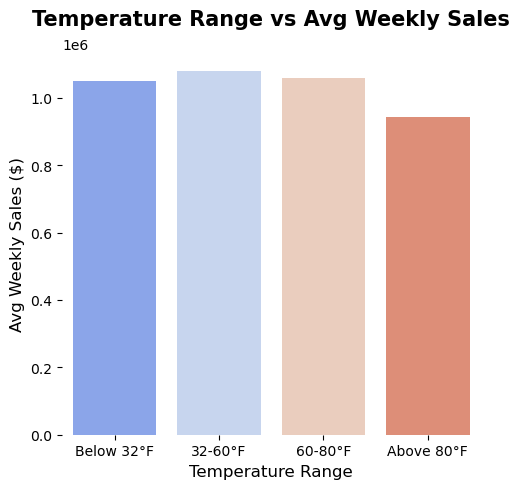

In [18]:
plt.figure(figsize=(5, 5))
ax = sns.barplot(
    data=c,
    x="Temp_Group",
    y="Avg_Sales",
    palette="coolwarm",
    hue="Temp_Group",
    legend=False
)
plt.title("Temperature Range vs Avg Weekly Sales", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Temperature Range", fontsize=12)
plt.ylabel("Avg Weekly Sales ($)", fontsize=12)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

#  Which month consistently generates the most revenue?

In [19]:
c = df.groupby("Year").agg(Total_Sales=("Weekly_Sales", "sum")).round(2).reset_index()
c

,Year,Total_Sales
0,2010,2.288886e+09
1,2011,2.448200e+09
2,2012,2.000133e+09


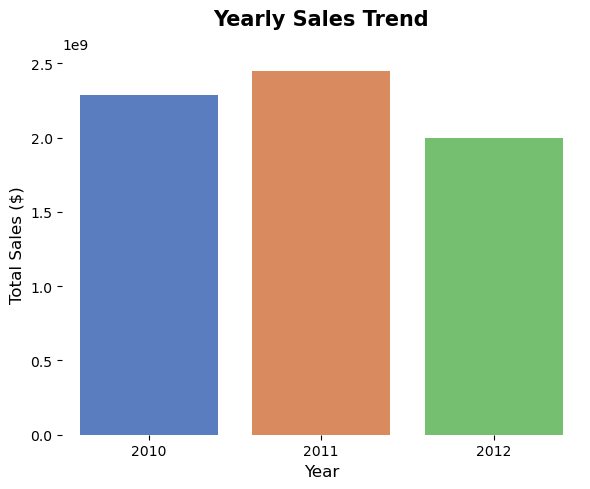

In [20]:
plt.figure(figsize=(6, 5))
ax = sns.barplot(
    data=c,
    x="Year",
    y="Total_Sales",
    palette="muted",
    hue="Year",
    legend=False
)
plt.title("Yearly Sales Trend", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()